In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch.nn 

from torch.func import (vmap, jacrev)

In [28]:
def kin_unicycle(t, x, control_input):
    v, w = control_input  
    dx = np.zeros(3)
    dx[0] = np.cos(x[2]) * v
    dx[1] = np.sin(x[2]) * v
    dx[2] = w
    return dx

In [32]:
N_sample = 800 # number of trajectory for type
# ps: full dataset will be [n_sample * 8, 100, 2]

len_traj = 10 # number of step for traj

# define range of controls:  +-1 m/s for v and +-1 rad/s for w
input_range_pos = np.array([-0.25, +1])
input_range_neg = np.array([-1, 0.25])

# define 8 "type" of trajectory:
trajectory_input = []

# 1 straight line forward -> [v > 0, w = 0]
v = np.random.uniform(*input_range_pos, (N_sample, len_traj, 1))
w = np.zeros((N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 2 straight line backward -> [v < 0, w = 0]
v = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
w = np.zeros((N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 3 arc of circle (left) forward ->  [v > 0, w > 0]
v = np.random.uniform(*input_range_pos, (N_sample, len_traj, 1))
w = np.random.uniform(*input_range_pos, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 4 arc of circle (left) backward -> [v < 0, w > 0]
v = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
w = np.random.uniform(*input_range_pos, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 5 arc of circle (right) forward -> [v > 0, w < 0]
v = np.random.uniform(*input_range_pos, (N_sample, len_traj, 1))
w = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 6 arc of circle (right) backward ->  [v < 0, w < 0]
v = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
w = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 7 pure rotation (right) -> [v = 0, w > 0]
v = np.zeros((N_sample, len_traj, 1))
w = np.random.uniform(*input_range_pos,  (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

# 8 pure rotation (left) -> [v = 0, w < 0]
v = np.zeros((N_sample, len_traj, 1))
w = np.random.uniform(*input_range_neg, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))


# 9 zero input + super small noise (+-0,05)
v = np.zeros((N_sample, len_traj, 1)) + np.random.uniform(-0.09, 0.09, (N_sample, len_traj, 1))
w = np.zeros((N_sample, len_traj, 1)) + np.random.uniform(-0.09, 0.09, (N_sample, len_traj, 1))
trajectory_input.append(np.concatenate([v, w], axis=-1))

input_dataset = np.concatenate(trajectory_input, axis=0)

In [33]:
n_step_constant_input = 10
delta_t_for_step = 0.01

print('MAX_RANGE FOR SINGLE TRANSITION:')
n_step_constant_input * delta_t_for_step

MAX_RANGE FOR SINGLE TRANSITION:


0.1

In [6]:
# discretize the input:

for i in range(0, input_dataset.shape[1], n_step_constant_input):
    input_dataset[:, i:i+n_step_constant_input, :] = input_dataset[:, i, :][:, np.newaxis, :]

In [7]:
input_dataset.reshape(-1, N_sample, len_traj, 2).shape

(9, 1, 5, 2)

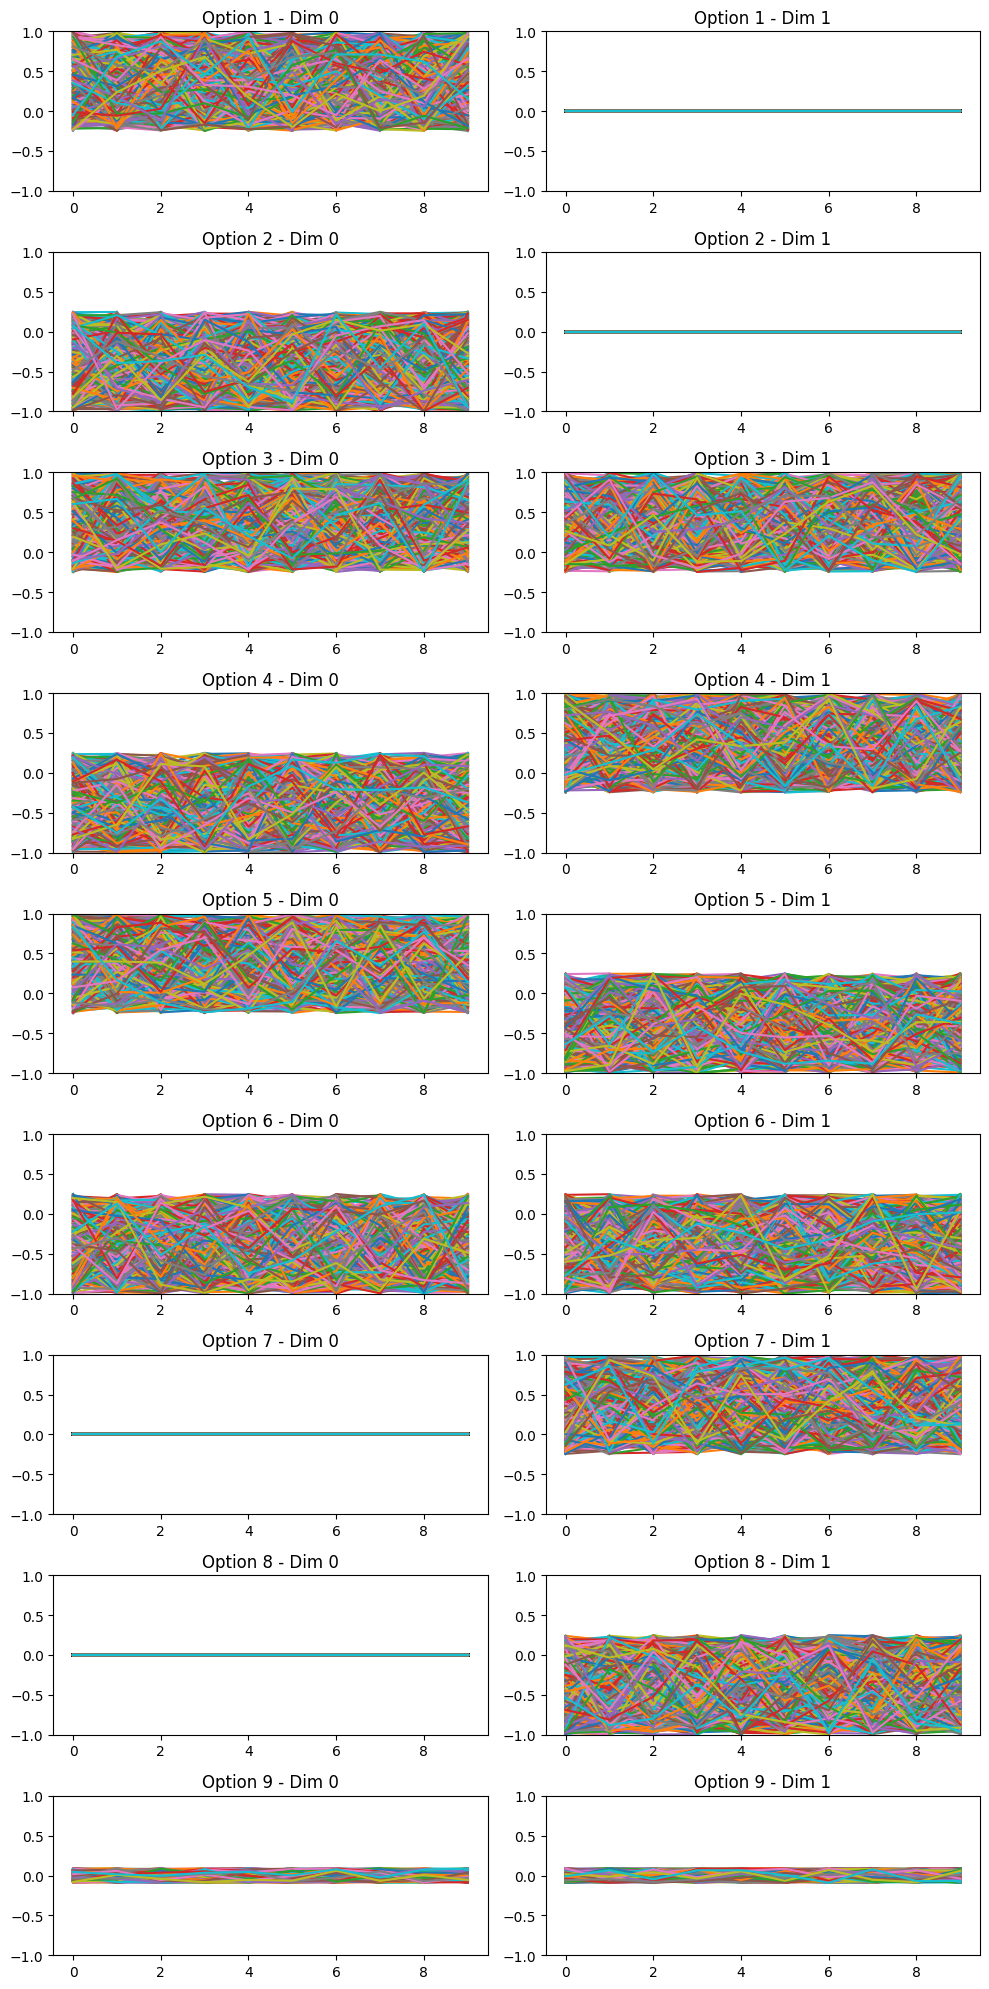

In [34]:
# plot the discretize input
import matplotlib.pyplot as plt
import numpy as np

# Assuming `input_dataset` is your tensor with shape (N*8, 100, 2)


# Create the subplot grid
fig, axes = plt.subplots(9, 2, figsize=(10, 20))  # 9 rows, 2 columns

# Loop over the 8 options (reshape input for clarity)
reshaped_dataset = input_dataset.reshape(-1, N_sample, len_traj, 2)

for i in range(9):  # Loop over the 8 options
    # Plot the 0th dimension in the left column (axes[i, 0])
    for j in range(N_sample):
        axes[i, 0].plot(reshaped_dataset[i, j, :, 0], label=f'Sample {j+1}')
    axes[i, 0].set_title(f'Option {i+1} - Dim 0')
    axes[i, 0].set_ylim(-1, 1)

    # Plot the 1st dimension in the right column (axes[i, 1])
    for j in range(N_sample):
        axes[i, 1].plot(reshaped_dataset[i, j, :, 1], label=f'Sample {j+1}')
    axes[i, 1].set_title(f'Option {i+1} - Dim 1')
    axes[i, 1].set_ylim(-1, 1)


# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [35]:
delta_t_for_step, n_step_constant_input, "transtition time", delta_t_for_step * n_step_constant_input

(0.01, 10, 'transtition time', 0.1)

In [36]:
time_range = [0.0, len_traj*delta_t_for_step]
time_points = np.arange(time_range[0], time_range[1]+delta_t_for_step, delta_t_for_step)

In [41]:
#@ generate the trajectory

import sys


k = n_step_constant_input
X, Y = [], []
for traj in range(len(input_dataset)):
    traj_input = input_dataset[traj, :, :]

    # integrate the trajectory 
    initial_state = np.random.randn(3)
    states = [initial_state]
    controls = []
    times = [np.array([0.0])]
    for i in range(0, len(time_points)-1):

        t_span = [time_points[i], time_points[i+1]]
        control = traj_input[i, :]
        sol = solve_ivp(
            kin_unicycle,
            t_span, 
            states[-1], # last state as initial state
            args=(control,),
            t_eval=[t_span[1]], 
            method='RK45'
            )
        
        states.append(sol.y.squeeze())
        times.append(sol.t)
        controls.append(control)
        
    s = np.stack(states)
    c = np.stack(controls)
    t = np.stack(times)
    
    # create sample for dataset
    X_traj_i, Y_traj_i = [], []
    for i in range(0, len(c), k):
        x0 = s[i][np.newaxis, :].repeat(k, axis=0)
        # print(f"x0: \n{x0}")
        
        c_substep = c[i:i+k]
        t = np.arange(0, delta_t_for_step * k, delta_t_for_step)[:, np.newaxis]
        # print(f"c_substep:\n {c_substep}")
        # print(f"t:\n {t}")

        x = np.hstack([x0, c_substep, t])
        X_traj_i.append(x)
        # print(f"x: \n{x}")

        y = s[i:i+k]
        Y_traj_i.append(y)
        # print(f"y:\n {y}")
        
        # sys.exit(0)

    X.append(np.concatenate(X_traj_i))
    Y.append(np.concatenate(Y_traj_i)) 

X = np.stack(X).reshape(-1, len_traj, 6)
Y = np.stack(Y).reshape(-1, len_traj, 3)

print(X.shape)

(7200, 10, 6)


In [17]:
x_max, x_min = Y[:, 0].max(), Y[:, 0].min()
y_max, y_min = Y[:, 1].max(), Y[:, 1].min()
theta_max, theta_min = Y[:, 2].max(), Y[:, 2].min()

v_max, v_min = X[:, :, 3].max(), X[:, :, 3].min()
w_max, w_min = X[:, :, 4].max(), X[:, :, 4].min()
t_max, t_min = X[:, :, 5].max(), X[:, :, 5].min()

In [18]:
max_range = torch.tensor(
    [x_max, y_max, theta_max, v_max, w_max, t_max],
    dtype=torch.float32
)

min_range = torch.tensor(
    [x_min, y_min, theta_min, v_min, w_min, t_min],
    dtype=torch.float32
)

dataset_range = (max_range, min_range)

In [19]:
dataset_range
# X Y Theta, V, W, time

(tensor([5.6094, 5.6092, 5.6091, 0.9999, 1.0000, 0.0900]),
 tensor([-5.1768, -5.1780, -5.1792, -0.9998, -1.0000,  0.0000]))

In [20]:
# shuffle the dataset and split into train and test
idx = np.random.randint(0, X.shape[0], X.shape[0])
X = X[idx]
Y = Y[idx]

split = int(0.8 * X.shape[0])
X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

In [21]:
class dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, device='cuda'):
        self.X = X.to(device)
        self.Y = Y.to(device)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [22]:
train_dataset = dataset(X_train, Y_train)   
test_dataset = dataset(X_test, Y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [23]:

class MLP(torch.nn.Module):

    def __init__(
        self,
        state_dim,
        input_dim,
        latent_dim,
        n_hidden_layer=2,
        time=False
    ):
        super(MLP, self).__init__()

        self.input_shape = state_dim + input_dim
        self.state_dim = state_dim

        if time:
            self.input_shape += 1

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(self.input_shape, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, state_dim),
        )

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x has dimension [batch_size, state_dim + action_dim + state_dim]
        """
        return self.fc(x)




In [24]:
def uniKinTorch(x, u):

    if x.ndim == 1:
        x = x.unsqueeze(0)
    if u.ndim == 1:
        u = u.unsqueeze(0)

    theta = x[:, 2]
    v = u[:, 0]
    w = u[:, 1]

    dx = torch.zeros_like(x)
    dx[:, 0] = torch.cos(theta) * v
    dx[:, 1] = torch.sin(theta) * v
    dx[:, 2] = w

    return dx

In [25]:
from dataclasses import dataclass

@dataclass
class PinnParams:

    state_dim = 3
    input_dim = 2

    batch_size = 1024
    particle_sample_for_grad = 1024
    particle_sample_for_zero_vel = 1024

    latent_dim = 124
    n_hidden_layer = 2
    model_path = None
    use_pretrain = None

    imit_loss_weight = 1.0
    boundary_loss_weight = 1.0
    physic_loss_weight = 1.0

    lr = 1e-5
    weight_decay = 1e-8


In [26]:

class Pinn_learner:


    def __init__(
        self,
        ode_fn,
        params,    
        input_range,
        dataset_train,
        dataset_test=None,
        use_pretrain=False, 
        device="cuda"):
        
        
        # robot model, dynamics
        self.state_dim = params.state_dim
        self.input_dim = params.input_dim
        self.ode_fn = ode_fn


        self.model_path = params.model_path
        self.device = device
        self.model = MLP(
            state_dim=params.state_dim,
            input_dim=params.input_dim,
            n_hidden_layer=params.n_hidden_layer,
            latent_dim=params.latent_dim,
            time=True
        ).to(self.device)

        if params.use_pretrain:
            self.model.load_state_dict(torch.load(self.model_path, weights_only=True))
        
        # dataset 
        self.dataset_train = dataset_train
        self.dataloader = torch.utils.data.DataLoader(
            self.dataset_train, 
            batch_size=params.batch_size, 
            shuffle=True
        )

        self.dataset_test = dataset_test
        self.dataloader_test = torch.utils.data.DataLoader(
            self.dataset_test,
            batch_size=len(self.dataset_test),
            shuffle=False
        )

        self.particle_batch_size_boundary = params.particle_sample_for_grad
        self.particle_batch_size_gradient = params.particle_sample_for_zero_vel

        self.max_range = input_range[0].to(self.device)
        self.min_range = input_range[1].to(self.device) 

        # training component 
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=params.lr,
            weight_decay=params.weight_decay
        )

        self.imit_loss_weight = params.imit_loss_weight
        self.boundary_loss_weight = params.boundary_loss_weight
        self.physic_loss_weight = params.physic_loss_weight

        self.mse = torch.nn.MSELoss()

    # training functions
    # -------------------
    def calc_loss(self, batch):
        
        statistics = {}
        loss = 0

        if self.imit_loss_weight > 0:
            imit_loss = self.calc_mse_loss(batch)
            statistics['imit_loss'] = imit_loss.item()
            loss += imit_loss
        
        if self.boundary_loss_weight > 0:
            boundary_loss = self.calc_boundary_loss()
            statistics['boundary_loss'] = boundary_loss.item()
            loss += boundary_loss

        if self.physic_loss_weight > 0:
            physic_loss = self.calc_physic_loss()
            statistics['physic_loss'] = physic_loss.item()
            loss += physic_loss

        statistics['total_loss'] = loss.item()

        return loss, statistics

    def train_step(self):
        for i, batch in enumerate(self.dataloader):
            self.optimizer.zero_grad()
            loss, stat = self.calc_loss(batch)
            loss.backward()
            self.optimizer.step()
        return stat


    # loss definition
    # -------------------
    def calc_physic_loss(self):

        N_particle = self.particle_batch_size_gradient

        # sample the particle        
        sampled_input = torch.rand(N_particle, self.state_dim + self.input_dim + 1).to(self.device)
        # normalize the particle in the respective range

        sampled_input = sampled_input * (self.max_range - self.min_range) + self.min_range
        sampled_input.requires_grad = True

        # jacobian --> [batch, state_dim, (state_dim + input_dim + 1(time))]
        jac = vmap(jacrev(self.model))(sampled_input).squeeze()
        state_derivative_numeric = jac[:, :, -1]        

        # ode prediction
        state_derivative_analytic = self.ode_fn(
            sampled_input[:, :self.state_dim],
            sampled_input[:, self.state_dim:-1]
        )

        # error:  
        error = state_derivative_numeric - state_derivative_analytic

        # physics cost:
        physic_loss = torch.mean(error**2)

        return self.physic_loss_weight * physic_loss

    def calc_mse_loss(self, batch):
        X, Y = batch
        pred_y = self.model(X)
        return self.imit_loss_weight * self.mse(pred_y, Y)

    def calc_boundary_loss(self):
        N_particle = self.particle_batch_size_boundary

        # sample the particle
        sampled_input = torch.rand(N_particle, self.state_dim + self.input_dim + 1).to(self.device)
        
        # normalize in the respective range 
        sampled_input = sampled_input * (self.max_range - self.min_range) + self.min_range
        
        # zeros the velocity
        sampled_input[:, self.state_dim : self.state_dim+self.input_dim] = 0.0
        

        # 0 velocity means that we want to predict the initial state 
        # the models must be a kind of identity function 
        target_prediction = sampled_input[:, :self.state_dim].clone()

        sampled_input.requires_grad = True

        pred_output = self.model(sampled_input)
        boundary_loss = self.mse(pred_output, target_prediction)

        return self.boundary_loss_weight * boundary_loss


    def eval(self):
        with torch.no_grad():
            batch = next(iter(self.dataloader_test))
            loss = self.calc_mse_loss(batch)
            return loss.item()

In [27]:
learner = Pinn_learner(
    uniKinTorch,
    PinnParams, 
    dataset_train=train_dataset, 
    dataset_test=test_dataset,
    input_range=dataset_range
    )

log_loss_train = []
log_loss_test = []


In [123]:


for epoch in range(20_000):

    statistics = learner.train_step()
    log_loss_train.append(statistics)
    if epoch % 10 == 0:
        log_loss_test.append(learner.eval())
        print(f"Epoch {epoch} : trained for: {len(log_loss_train)} - \n",
              f"TOT Loss: {statistics['total_loss']} ",
              f"Imitation Loss: {statistics['imit_loss']} ",
              f"Boundary Loss: {statistics['boundary_loss']} ", 
              f"Physic Loss: {statistics['physic_loss']} ",
              f"test imit loss: {log_loss_test[-1]}"
              )
        print()


Epoch 0 : trained for: 80285 - 
 TOT Loss: 7.5856983130506705e-06  Imitation Loss: 5.609772415482439e-07  Boundary Loss: 4.512645546128624e-07  Physic Loss: 6.573456630576402e-06  test imit loss: 6.491930548691016e-07

Epoch 10 : trained for: 80295 - 
 TOT Loss: 7.737319720035885e-06  Imitation Loss: 6.82777795191214e-07  Boundary Loss: 4.7397560365425306e-07  Physic Loss: 6.580566605407512e-06  test imit loss: 6.416096880457189e-07

Epoch 20 : trained for: 80305 - 
 TOT Loss: 7.518259280914208e-06  Imitation Loss: 5.300440193423128e-07  Boundary Loss: 4.2250758269801736e-07  Physic Loss: 6.565707735717297e-06  test imit loss: 6.321577643575438e-07

Epoch 30 : trained for: 80315 - 
 TOT Loss: 6.979294994380325e-06  Imitation Loss: 7.519881819462171e-07  Boundary Loss: 3.8163881299624336e-07  Physic Loss: 5.8456680562812835e-06  test imit loss: 6.403467409654695e-07

Epoch 40 : trained for: 80325 - 
 TOT Loss: 7.069177627272438e-06  Imitation Loss: 6.133265628704976e-07  Boundary Loss: 

KeyboardInterrupt: 

In [156]:
torch.save(learner.model.state_dict(), 'model_epochs_80_345_extra_small_input_maybe_to_many_ep.pth')

In [124]:

# Extracting values for each key
imit_loss = [entry['imit_loss'] for entry in log_loss_train]
boundary_loss = [entry['boundary_loss'] for entry in log_loss_train]
physic_loss = [entry['physic_loss'] for entry in log_loss_train]
total_loss = [entry['total_loss'] for entry in log_loss_train]

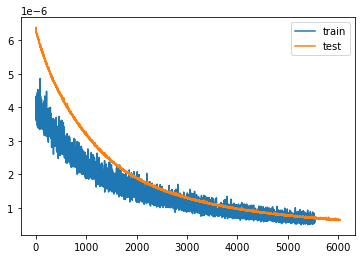

In [126]:
skipp_train = 25000
skipp_test = 2000
plt.plot(imit_loss[skipp_train::10], label='train')
plt.plot(np.array(log_loss_test)[skipp_test:], label='test')
plt.legend()

In [128]:
"n epochs" , len(total_loss)

('n epochs', 80348)

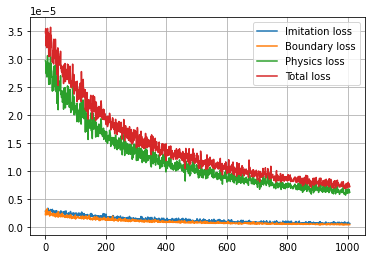

In [129]:
skipp = 30000
step = 50

plt.plot(imit_loss[skipp::step], label = 'Imitation loss')
plt.plot(boundary_loss[skipp::step], label = 'Boundary loss')
plt.plot(physic_loss[skipp::step], label = 'Physics loss')
plt.plot(total_loss[skipp::step], label = 'Total loss')
plt.grid()
plt.legend()

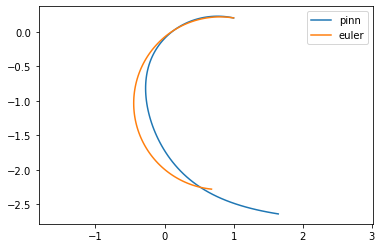

In [155]:

state_init = torch.Tensor([1, 0.2, 3]).to('cuda')
vel = torch.Tensor([0.5, 0.4]).to('cuda')
t = torch.Tensor([0.08]).to('cuda')

states = [state_init]

for _ in range(100):

    with torch.no_grad():
        input_pair = torch.cat([states[-1], vel, t]).to('cuda')
        state = learner.model(input_pair)
        states.append(state)

state = states[0]
states_model = [state]
for _ in range(100):

    x_dot = torch.cos(states_model[-1][2])*vel[0]
    y_dot = torch.sin(states_model[-1][2])*vel[0]
    theta_dot = vel[1]

    states_model.append(
        states_model[-1] + torch.Tensor([x_dot, y_dot, theta_dot]).to('cuda') * t
    )

state = torch.vstack(states).cpu().numpy()
state_model = torch.vstack(states_model).cpu().numpy()
plt.plot(state[:, 0], state[:, 1], label='pinn')
plt.plot(state_model[:, 0], state_model[:, 1], label='euler')
plt.axis('equal')
plt.legend()

In [67]:
max_range, min_range

(tensor([5.6094, 5.6092, 5.6091, 0.9999, 1.0000, 0.0900]),
 tensor([-5.1768, -5.1780, -5.1792, -0.9998, -1.0000,  0.0000]))